In [1]:
import pandas as pd 
import numpy as np
import random
import os 
import argparse
import json
import torch
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from torch import nn
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.utils.data import TensorDataset
from attrdict import AttrDict
from transformers import BertConfig, BertTokenizer, BertModel
from transformers import DistilBertModel, DistilBertTokenizer, DistilBertConfig, DistilBertForSequenceClassification
from transformers import RobertaModel, RobertaTokenizer, RobertaConfig, RobertaForSequenceClassification
from transformers import AdamW, get_linear_schedule_with_warmup

In [2]:
default_path = os.getcwd()
data_path = os.path.join(default_path, '../data')
base_model = os.path.join(default_path, '../base-model')
model_path = os.path.join(default_path, '../models')
config_path = os.path.join(default_path, '../config')
log_path = os.path.join(default_path, '../log')
config_file = "bert-base.json"

In [3]:
criteria = 4

In [4]:
X_train = pd.read_csv(os.path.join(data_path, 'BWS', 'score', f'bws_a{criteria}_score_train.csv'))
X_dev = pd.read_csv(os.path.join(data_path, 'BWS', 'score', f'bws_a{criteria}_score_val.csv'))
X_test = pd.read_csv(os.path.join(data_path, 'BWS', 'score', f'bws_a{criteria}_score_test.csv'))

In [5]:
X_train

,text,text_kor,label
0,"I often think ""what if I am just lazy"" but in...","나는 종종 ""그냥 게으르면 어떨까""라고 생각하지만, 실제로는 뇌가 거슬리는 생각으로...",7
1,The only thing is when i go home I drink my se...,유일한 것은 집에 가면 술을 마시고 잠을 자는 것이다. 왜냐하면 나는 내 인생에서 ...,3
2,I couldnt sleep at all because I didnt have my...,불면증 약이 없어서 잠을 전혀 못 잤어요,10
3,I often sleep during the daytime because I am ...,나는 너무 피곤해서 밤이 될 때까지 깨어 있을 수 없을 것 같아서 낮에 자주 잔다,5
4,The first few nights alone I just did not kno...,처음 며칠 밤은 혼자서 잠을 잘 수가 없었다,6
...,...,...,...
1147,Then when I get up I feel like my eyeballs are...,그리고 일어나면 눈알이 너무 아프고 아무리 자거나 낮잠을 자도 하품을 멈추지 않을 ...,8
1148,I remember feeling at peace as the chemicals o...,수면 부족으로 인한 지옥 같은 정신병이 일주일간 지속된 후 화학물질이 나를 덮쳤을 ...,2
1149,Still sleep suffered hygiene was lax for a b...,여전히 잠을 자는 것은 위생적이지 않았고 나는 어쨌든 집안일이나 청소를 많이 해본 ...,6
1150,it is so hard to sleep sometimes,때때로 잠을 자는 것은 너무 힘들다,7


In [6]:
reddit = pd.read_csv(os.path.join(data_path, 'reddit_dsm_ngram.csv'))
reddit.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
0,al526,depression,unremedied,I have had all of these problems for as long a...,post,1.262551e+09,al526,al526,35,0,True,False,False
1,t3_7djh5r,depression,j0siahs74,Yes! I have been having crazy ass dreams some...,comment,1.510909e+09,t1_dpy9scj,dpy9zxp,22,0,True,False,False
2,al526,depression,unremedied,So am I depressed? I am honestly unsure mysel...,post,1.262551e+09,al526,al526,25,0,True,False,False


In [7]:
model_name = 'roberta-base'   # RobertaModel

In [8]:
tokenizer = RobertaTokenizer.from_pretrained(model_name, model_max_length=128)
config = RobertaConfig.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name, config=config)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
with open(os.path.join(config_path, 'training_config.json')) as f:
    training_config = AttrDict(json.load(f))

In [10]:
training_config.device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

In [11]:
training_config.config_path = config_path
training_config.log_path = log_path
training_config.data_path = data_path
training_config.model_path = model_path 

In [12]:
training_config

AttrDict({'default_path': '../', 'data_path': 'C:\\Users\\lamda\\Desktop\\LAMDA_git\\DSM-5\\jupyter\\../data', 'log_path': 'C:\\Users\\lamda\\Desktop\\LAMDA_git\\DSM-5\\jupyter\\../log', 'model_path': 'C:\\Users\\lamda\\Desktop\\LAMDA_git\\DSM-5\\jupyter\\../models', 'config_path': 'C:\\Users\\lamda\\Desktop\\LAMDA_git\\DSM-5\\jupyter\\../config', 'seed': 42, 'train_batch_size': 8, 'device': device(type='cuda'), 'eval_batch_size': 8, 'num_epochs': 5, 'gradient_accumulation_steps': 1, 'warmup_proportion': 0, 'adam_epsilon': 1e-08, 'learning_rate': 5e-05, 'do_lower_case': False, 'no_cuda': False, 'max_steps': -1, 'logging_steps': 100})

In [13]:
training_config.learning_rate

5e-05

In [14]:
training_config.pad = 'max_length'
training_config.num_epochs = 10

In [15]:
config.max_position_embeddings = 128
config.max_position_embeddings

128

In [16]:
class DSMDataset(Dataset):
    def __init__(self, data_file):
        self.data = data_file
    
    def __len__(self):
        return len(self.data.label)
    
    def reset_index(self):
        self.data.reset_index(inplace=True, drop=True)
    
    def __getitem__(self, idx):
        '''
        return text, label
        '''
        self.reset_index()
        text = self.data.text[idx]
        label = self.data.label[idx]
        return text, label

In [17]:
class DSMProcessor():
    def __init__(self, config, training_config, tokenizer, truncation=True):
        self.tokenizer = tokenizer 
        self.max_len =  config.max_position_embeddings
        self.pad = training_config.pad
        self.batch_size = training_config.train_batch_size
        self.truncation = truncation
    
    def convert_data(self, data_file):
        context2 = None    # single sentence classification
        batch_encoding = self.tokenizer.batch_encode_plus(
            [(data_file[idx][0], context2) for idx in range(len(data_file))],   # text, 
            max_length = self.max_len,
            padding = self.pad,
            truncation = self.truncation
        )
        
        features = []
        for i in range(len(data_file)):
            inputs = {k: batch_encoding[k][i] for k in batch_encoding}
            try:
                inputs['label'] = data_file[i][1] 
            except:
                inputs['label'] = 0 
            # print(inputs)
            features.append(inputs)
        
        all_input_ids = torch.tensor([f['input_ids'] for f in features], dtype=torch.long)
        all_attention_mask = torch.tensor([f['attention_mask'] for f in features], dtype=torch.long)
        # all_token_type_ids = torch.tensor([f['token_type_ids'] for f in features], dtype=torch.long)
        all_labels = torch.tensor([f['label'] for f in features], dtype=torch.long)

        dataset = TensorDataset(all_input_ids, all_attention_mask, all_labels)
        return dataset
    
    def shuffle_data(self, dataset, data_type):
        if data_type == 'train':
            return RandomSampler(dataset)
        elif data_type == 'eval' or data_type == 'test':
            return SequentialSampler(dataset)
        
    def load_data(self, dataset, sampler):
        return DataLoader(dataset, sampler=sampler, batch_size=self.batch_size)

In [18]:
def RMSELoss(yhat,y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [19]:
class BertRegressor(nn.Module):
    def __init__(self, config, model):
        super(BertRegressor, self).__init__()
        self.model = model
        self.linear = nn.Linear(config.hidden_size, 128)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, 1)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.last_hidden_state[:, 0, :]
        # print(f'logits: {len(logits)}, {len(logits[0])}')
        x = self.linear(logits)
        x = self.relu(x)
        score = self.out(x)
        # print(f'score: {score}')
        return score 

In [20]:
class BertTrainer():
    def __init__(self, config, training_config, model, model_name, train_dataloader, eval_dataloader):
        self.config = config
        self.training_config = training_config
        self.model = model
        self.model_name = model_name
        self.train_dataloader = train_dataloader
        self.eval_dataloader = eval_dataloader
        
    def set_seed(self):
        random.seed(self.training_config.seed)
        np.random.seed(self.training_config.seed)
        torch.manual_seed(self.training_config.seed)
        if not self.training_config.no_cuda and torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.training_config.seed)
    
    def train(self):
        global_step = 0; nb_eval_steps = 0
        train_rmse = []; eval_rmse = []
        t_total = len(self.train_dataloader) // self.training_config.gradient_accumulation_steps * self.training_config.num_epochs

        optimizer = AdamW(self.model.parameters(), lr=self.training_config.learning_rate, eps=self.training_config.adam_epsilon)
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(t_total * self.training_config.warmup_proportion), \
                                                    num_training_steps=t_total)
        
        criterion = RMSELoss
        # criterion = nn.MSELoss()
        best_loss = 9999 
        
        self.model.zero_grad()
        for epoch in range(int(self.training_config.num_epochs)):
            train_loss = 0.0; eval_loss = 0.0 
            
            for step, batch in enumerate(self.train_dataloader):
                self.model.train()
                batch = tuple(t.to(self.training_config.device) for t in batch)
                inputs = {
                    "input_ids": batch[0],
                    "attention_mask": batch[1],
                    # "token_type_ids": batch[2],
                }
                outputs = self.model(**inputs)
                # print(f'output: {type(outputs)}, {outputs.squeeze}')
                label = batch[2]
                # print(f'label: {label}')
                # print(f'output: {outputs}, {outputs.squeeze()}')
                loss = criterion(outputs.squeeze(), batch[2].type_as(outputs))
                loss.backward()
                
                train_loss += loss.item()
                # torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.training_config.max_grad_norm)
                optimizer.step()
                scheduler.step()
                
                self.model.zero_grad()
            
            print(f'epoch: {epoch + 1} done, train_loss: {train_loss / len(self.train_dataloader)}')
            train_rmse.append(train_loss / len(self.train_dataloader))

            for step2, batch2 in enumerate(self.eval_dataloader):
                self.model.eval()
                batch2 = tuple(t.to(self.training_config.device) for t in batch2)

                with torch.no_grad():
                    inputs = {
                        "input_ids": batch2[0],
                        "attention_mask": batch2[1],
                        # "token_type_ids": batch2[2],
                    }
                    label2 = batch2[2]
                    outputs = self.model(**inputs)
                    tmp_eval_loss = criterion(outputs.squeeze(), label2.type_as(outputs))
                    eval_loss += tmp_eval_loss.mean().item()
                    
                nb_eval_steps += 1

            eval_loss = eval_loss / nb_eval_steps
            eval_rmse.append(eval_loss)

        # self.save_model(os.path.join(self.training_config.model_path, self.model_name, f'bert_bws_5.pt'))
        # self.save_log(train_rmse, eval_rmse, epoch+1)
        return train_rmse, eval_rmse
            
    def save_log(self, train_mse, eval_mse, epoch):
        with open(os.path.join(self.training_config.log_path, self.model_name, f'train_{epoch}_mse.pickle'), 'wb') as f:
            pickle.dump(train_mse, f, pickle.HIGHEST_PROTOCOL)  
        
        with open(os.path.join(self.training_config.log_path, self.model_name, f'eval_{epoch}_mse.pickle'), 'wb') as f:
            pickle.dump(eval_mse, f, pickle.HIGHEST_PROTOCOL)  
    
    def save_model(self, model_name):
        torch.save(self.model.state_dict(), model_name)

In [21]:
train_file = DSMDataset(X_train)
val_file = DSMDataset(X_dev)
test_file = DSMDataset(X_test)

In [22]:
config.max_position_embeddings = 128
config.max_position_embeddings

128

In [23]:
bert_processor = DSMProcessor(config, training_config, tokenizer)

In [24]:
train_dataset = bert_processor.convert_data(train_file)
val_dataset = bert_processor.convert_data(val_file)
test_dataset = bert_processor.convert_data(test_file)

In [25]:
train_sampler = bert_processor.shuffle_data(train_dataset, 'train')
val_sampler = bert_processor.shuffle_data(val_dataset, 'eval')
test_sampler = bert_processor.shuffle_data(test_dataset, 'test')

In [26]:
train_dataloader = bert_processor.load_data(train_dataset, train_sampler)
val_dataloader = bert_processor.load_data(val_dataset, val_sampler)
test_dataloader = bert_processor.load_data(test_dataset, test_sampler)

In [27]:
len(train_dataloader), len(val_dataloader)

(144, 16)

In [28]:
model_reg = BertRegressor(config, model).to(training_config.device)  

In [29]:
bert_trainer = BertTrainer(config, training_config, model_reg, model_name, train_dataloader, val_dataloader)

In [30]:
train_mse, eval_mse = bert_trainer.train()

C:\Users\lamda\.conda\envs\aaai\lib\site-packages\transformers\optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


epoch: 1 done, train_loss: 2.7562642420331636
epoch: 2 done, train_loss: 2.2526413347158165
epoch: 3 done, train_loss: 1.9216867697735627
epoch: 4 done, train_loss: 1.6331154116325908
epoch: 5 done, train_loss: 1.3087618427558079
epoch: 6 done, train_loss: 1.0885209581918187
epoch: 7 done, train_loss: 0.9262876510620117
epoch: 8 done, train_loss: 0.7600824423134327
epoch: 9 done, train_loss: 0.6558453320629067
epoch: 10 done, train_loss: 0.5670087111906873


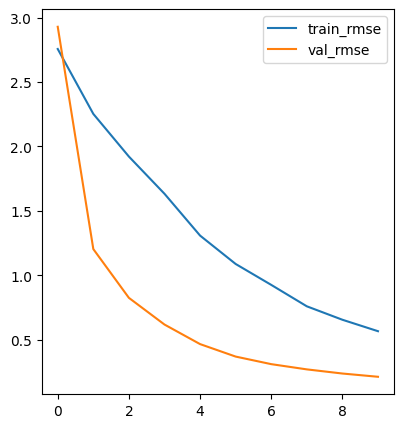

In [31]:
num_epochs = list(range(len(train_mse)))
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(list(range(len(train_mse))), train_mse, label='train_rmse')
plt.plot(list(range(len(eval_mse))), eval_mse, label='val_rmse')

plt.legend()
plt.show()

In [32]:
bert_trainer.save_model(os.path.join(model_path, f'roberta_a{criteria}_e10.pt'))

In [33]:
class BertRegTester():
    def __init__(self, training_config, model):
        self.training_config = training_config
        self.model = model

    def get_label(self, test_dataloader, test_type):
        '''
        test_type: 0  -> Test dataset 
        test_type: 1  -> Test sentence
        '''
        preds = []
        labels = []

        for batch in test_dataloader:
            self.model.eval()   # self 안 붙이면 이상한 Output (BaseModelOutputWithPoolingAndCrossAttentions) 출력 
            batch = tuple(t.to(self.training_config.device) for t in batch)   # args.device: cuda 
            with torch.no_grad():
                inputs = {
                    "input_ids": batch[0],
                    "attention_mask": batch[1],
                    "token_type_ids": batch[2],
                }
                outputs = self.model(**inputs)
                # print(outputs, outputs.squeeze().detach().cpu().numpy())
                # print(len(preds))
                if test_type == 0:
                    try:
                        preds.extend(list(outputs.squeeze().detach().cpu().numpy()))
                    except:
                        preds.append(outputs.squeeze().detach().cpu().numpy())
                elif test_type == 1:
                    preds.extend(outputs[0].detach().cpu().numpy())            
            label = batch[3].detach().cpu().numpy()
            labels.extend(label)
        return preds, labels 

In [34]:
bert_tester = BertRegTester(training_config, model_reg)

In [ ]:
import time 

start = time.time()
y_pred, y_true = bert_tester.get_label(test_dataloader, 0)
print(f'소요 시간: {time.time() - start}')

In [ ]:
y_pred[:3] ,y_true[:3]

In [ ]:
def RMSELoss(yhat,y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [ ]:
criterion = RMSELoss

In [ ]:
loss = criterion(torch.Tensor(y_pred), torch.Tensor((y_true)))
loss

In [ ]:
r2score = R2Score()
r2score(torch.Tensor(y_pred), torch.Tensor(y_true))

In [ ]:
conv = ['hey', 'I feel very depressed', 'I feed depressed', 'I feel sad', 'I cry everyday', 'I went to school', 'I want to die']
dep_test = pd.DataFrame(conv, columns=['text'])
dep_test['label'] = 9999

In [ ]:
test_file = BertDataset(dep_test)
test_dataset = bert_processor.convert_data(test_file)
test_sampler = bert_processor.shuffle_data(test_dataset, 'test')
test_dataloader = bert_processor.load_data(test_dataset, test_sampler)

In [ ]:
y_pred, y_true = bert_tester.get_label(test_dataloader, 0)

In [ ]:
dep_test['label'] = [pred for pred in y_pred]
dep_test

In [ ]:
untagged_file = BertDataset(untagged_data)
untagged_dataset = bert_processor.convert_data(untagged_file)
untagged_sampler = bert_processor.shuffle_data(untagged_dataset, 'test')
untagged_dataloader = bert_processor.load_data(untagged_dataset, untagged_sampler)

In [ ]:
untagged_file

In [ ]:
len(untagged_data)

In [ ]:
y_pred, y_true = bert_tester.get_label(untagged_dataloader, 0)

In [ ]:
len(y_pred), len(y_true)

In [ ]:
y_pred[-1]

In [ ]:
def convert_score(score):
    if score < 0:
        score = 0
    elif score >= 11:
        score = 10
    return int(score)

In [ ]:
untagged_data['pseudo'] = y_pred
untagged_data['pseudo'] = untagged_data.pseudo.apply(convert_score)
untagged_data

In [ ]:
untagged_data.groupby('pseudo').count()

In [ ]:
untagged_data.to_csv(os.path.join(data_path, 'untagged_a3_pseudo.csv'), index=False)

In [ ]:
a1_train, a1_test = train_test_split(untagged_data, test_size=0.2, random_state=42) #, stratify=a1.label)
a1_train, a1_dev = train_test_split(a1_train, test_size=0.1, random_state=42) #, stratify=a1_train.label)

In [ ]:
a1_train.to_csv(os.path.join(data_path, 'untagged_a3_pseudo_train.csv'), index=False)
a1_dev.to_csv(os.path.join(data_path, 'untagged_a3_pseudo_val.csv'), index=False)
a1_test.to_csv(os.path.join(data_path, 'untagged_a3_pseudo_test.csv'), index=False)